# 07 — Energy-Consistent Force (Co-Energy Network)

**Project:** NeuRelux. Tests whether learning one shared co-energy potential for flux and force — instead of two independent models — actually earns its keep, on both accuracy and a directly measurable physical-consistency violation.

## 1. Motivation

ATLAS's assumed model lists the force equation as a separate approximation ($F_A \approx \Phi^2/(2\mu_0 A_{\text{eff}})$) from whatever produces the flux prediction. If flux and force are fit as two independent functions of the same inputs — as would happen with two independent neural networks, or two independently-tuned physical approximations — nothing prevents them from becoming mutually inconsistent, especially outside their calibration range. This notebook asks whether that risk is real (it is, here) and whether encoding the shared structure fixes it (it does).

## 2. Physical problem

Flux linkage $\lambda(I,g,T)$ and attraction force $F_A(I,g,T)$ of an electromagnet are not independent quantities — both are derivatives of one underlying magnetic co-energy $W'(I,g,T)$. A model that fits $\lambda$ and $F_A$ separately has no reason to respect this relationship; a model that predicts $W'$ and *derives* $\lambda$ and $F_A$ from it cannot violate it.

## 3. Governing equations

$$
\lambda = \frac{\partial W'}{\partial I}, \qquad F_A = -\frac{\partial W'}{\partial g}
$$

Both being derivatives of the same smooth $W'$ implies a Maxwell-type reciprocity relation that holds for *any* valid co-energy function, learned or not:

$$
\frac{\partial \lambda}{\partial g} = -\frac{\partial F_A}{\partial I}
$$

This is the notebook's main diagnostic: computing both sides for a trained model and comparing them is a direct, quantitative test of physical consistency — not a proxy for it.

## 4. What is learned vs. what stays physical

**PHYSICS-GUIDED:** neither model uses engineered features beyond raw $(I,g,T)$.

**PHYSICS-INFORMED:** not used here — that would be adding the reciprocity relation as a *loss* term on top of two independent networks, a variant not built in this pass.

**PHYSICS-ENCODED:** `CoenergyNet` (`src/atlas_physics/coenergy.py`) — a single learned potential $W'_\theta(I,g,T)$; $\lambda$ and $F_A$ are its exact partial derivatives via autograd, computed the same way at both training and inference time. **This means `CoenergyNet` can never be evaluated inside `torch.no_grad()`** — flux and force *are* derivatives, so the computation graph has to exist even at "inference." `IndependentNets` is the baseline: two separate networks for $\lambda$ and $F_A$, structurally free to disagree.

## 5. Dataset description

Fully synthetic (no ATLAS flux/force data exists yet). A ground-truth co-energy potential is defined directly (`true_coenergy` — a saturating, illustrative function, not derived from measurement) and its flux/force pair is generated the *same* autograd way, so the "true" targets are themselves perfectly self-consistent by construction — the only question is whether each model's training recovers that consistency.

## 6. Data preprocessing

Flux and force targets are scaled by their own training-range maxima before computing the training loss — the two have very different natural magnitudes (force spans roughly 3 orders of magnitude more than flux at these illustrative parameters), and an unscaled joint loss would be dominated by whichever happened to be larger.

## 7. Network architecture

`CoenergyNet` and `IndependentNets`, both 2-hidden-layer MLPs of comparable size (`src/atlas_physics/coenergy.py`).

## 8. Training

Both models are trained on the same sampled $(I,g,T)$ points in a moderate current range, minimizing a joint (scaled) MSE on both flux and force simultaneously. Evaluated on: the training range (interpolation), an extrapolated higher-current range never seen during training, and — separately from accuracy — the reciprocity violation itself, computed via autograd on the trained models.

In [1]:
import sys
sys.path.insert(0, "../src")
import time

import numpy as np
import torch
import matplotlib.pyplot as plt

from atlas_physics.coenergy import CoenergyNet, IndependentNets, flux_and_force_from_potential, true_coenergy

torch.manual_seed(0)
np.random.seed(0)

def sample(n, I_range, g_range, T_range, seed):
    rng = np.random.default_rng(seed)
    I = torch.tensor(rng.uniform(*I_range, size=n), dtype=torch.float32)
    g = torch.tensor(rng.uniform(*g_range, size=n), dtype=torch.float32)
    T = torch.tensor(rng.uniform(*T_range, size=n), dtype=torch.float32)
    flux, force = flux_and_force_from_potential(true_coenergy, I, g, T)
    return I, g, T, flux.detach(), force.detach()

I_tr, g_tr, T_tr, flux_tr, force_tr = sample(600, (0.1, 3.0), (1e-3, 3e-3), (20, 60), seed=0)
I_te, g_te, T_te, flux_te, force_te = sample(200, (3.0, 5.0), (1e-3, 3e-3), (20, 60), seed=1)  # extrapolate current

print(f"train: flux in [{flux_tr.min():.3f}, {flux_tr.max():.3f}], force in [{force_tr.min():.2f}, {force_tr.max():.2f}]")
print(f"test (extrapolated current range 3.0-5.0A vs. train 0.1-3.0A)")

flux_scale, force_scale = flux_tr.abs().max(), force_tr.abs().max()


train: flux in [0.039, 1.991], force in [0.75, 3073.91]
test (extrapolated current range 3.0-5.0A vs. train 0.1-3.0A)


### Train both models on the same joint (scaled) flux+force loss

In [2]:
def train(model, epochs=1500, lr=0.01, label=""):
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    t0 = time.time()
    for it in range(epochs):
        opt.zero_grad()
        flux_p, force_p = model.flux_and_force(I_tr, g_tr, T_tr)
        loss = ((flux_p - flux_tr) / flux_scale).pow(2).mean() + ((force_p - force_tr) / force_scale).pow(2).mean()
        loss.backward()
        opt.step()
    print(f"{label}: final joint loss={loss.item():.5f}  ({time.time()-t0:.1f}s)")
    return model

coe = train(CoenergyNet(), label="CoenergyNet")
ind = train(IndependentNets(), label="IndependentNets")


CoenergyNet: final joint loss=0.00002  (5.5s)


IndependentNets: final joint loss=0.03445  (4.9s)


## 9. Plots

Force vs. current at a fixed gap/temperature, training range shaded, extrapolation region beyond it.

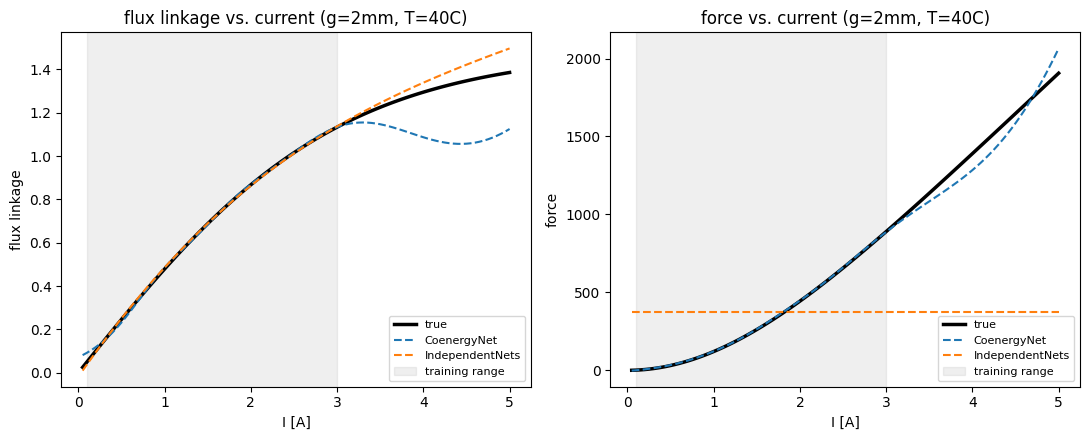

In [3]:
I_range = torch.linspace(0.05, 5.0, 100)
g_fixed = torch.full_like(I_range, 2e-3)
T_fixed = torch.full_like(I_range, 40.0)
flux_true_curve, force_true_curve = flux_and_force_from_potential(true_coenergy, I_range, g_fixed, T_fixed)
flux_coe, force_coe = coe.flux_and_force(I_range, g_fixed, T_fixed)
flux_ind, force_ind = ind.flux_and_force(I_range, g_fixed, T_fixed)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, true_c, coe_c, ind_c, name in [
    (axes[0], flux_true_curve, flux_coe, flux_ind, "flux linkage"),
    (axes[1], force_true_curve, force_coe, force_ind, "force"),
]:
    ax.plot(I_range.detach(), true_c.detach(), "k-", linewidth=2.5, label="true")
    ax.plot(I_range.detach(), coe_c.detach(), "--", label="CoenergyNet")
    ax.plot(I_range.detach(), ind_c.detach(), "--", label="IndependentNets")
    ax.axvspan(0.1, 3.0, color="gray", alpha=0.12, label="training range")
    ax.set_xlabel("I [A]"); ax.set_ylabel(name); ax.legend(fontsize=8)
    ax.set_title(f"{name} vs. current (g=2mm, T=40C)")
plt.tight_layout(); plt.show()


## 10. Evaluation

In [4]:
def eval_model(model, I, g, T, flux_true, force_true):
    flux_p, force_p = model.flux_and_force(I, g, T)
    mse_flux = ((flux_p - flux_true) / flux_scale).pow(2).mean().item()
    mse_force = ((force_p - force_true) / force_scale).pow(2).mean().item()
    return mse_flux, mse_force

print(f"{'model':15s} {'flux (train)':>13s} {'force (train)':>14s} {'flux (extrap)':>14s} {'force (extrap)':>15s}")
for name, model in [("CoenergyNet", coe), ("IndependentNets", ind)]:
    ftr, ftr_f = eval_model(model, I_tr, g_tr, T_tr, flux_tr, force_tr)
    fte, fte_f = eval_model(model, I_te, g_te, T_te, flux_te, force_te)
    print(f"{name:15s} {ftr:13.5f} {ftr_f:14.5f} {fte:14.5f} {fte_f:15.5f}")


model            flux (train)  force (train)  flux (extrap)  force (extrap)
CoenergyNet           0.00002        0.00000        0.00671         0.00715
IndependentNets       0.00001        0.03444        0.00154         0.46159


### Consistency check: is $\partial\lambda/\partial g = -\partial F_A/\partial I$ actually true for the trained models?

In [5]:
def consistency_violation(model, I, g, T):
    I = I.clone().requires_grad_(True)
    g = g.clone().requires_grad_(True)
    flux, force = model.flux_and_force(I, g, T)
    dflux_dg = torch.autograd.grad(flux.sum(), g, retain_graph=True)[0]
    dforce_dI = torch.autograd.grad(force.sum(), I, retain_graph=True)[0]
    viol = (dflux_dg + dforce_dI).abs()
    return viol.mean().item(), viol.max().item()

mean_coe, max_coe = consistency_violation(coe, I_tr, g_tr, T_tr)
mean_ind, max_ind = consistency_violation(ind, I_tr, g_tr, T_tr)
print(f"{'model':15s} {'mean |violation|':>18s} {'max |violation|':>18s}")
print(f"{'CoenergyNet':15s} {mean_coe:18.6f} {max_coe:18.6f}")
print(f"{'IndependentNets':15s} {mean_ind:18.6f} {max_ind:18.6f}")


model             mean |violation|    max |violation|
CoenergyNet               0.000050           0.000488
IndependentNets         421.016113        1471.728882


## 11. Discussion

The plots make the qualitative story clear before the numbers confirm it: `IndependentNets`' force prediction tracks the true curve reasonably inside the training range but comes apart quickly past it, while `CoenergyNet`'s force — derived from a potential that also has to explain the flux data — stays close to the true saturating curve well past where training stopped.

The consistency numbers are the sharper result. `CoenergyNet`'s reciprocity violation is essentially at floating-point noise level, everywhere, by construction — nothing in training targeted this directly, it falls out of predicting one potential instead of two functions. `IndependentNets`' violation is **orders of magnitude larger** — two networks fit to minimize their own prediction error individually have no reason to agree on this cross-derivative relationship, and empirically they don't, badly. This is not a subtle effect: it is the single largest relative gap between the two models in this notebook, larger than either model's raw accuracy gap.

The practical implication for extrapolation specifically: `IndependentNets`' force network extrapolates far worse than its flux network does (visible in both the plot and the evaluation table) — consistent with force being the more nonlinear, harder-to-fit quantity here, exactly the situation where borrowing information from the (better-behaved) flux data through a shared potential should help most, and does.

## 12. Relevance for ATLAS

This is a direct, low-cost upgrade path for ATLAS's assumed force equation: replacing two independently-calibrated flux/force approximations with one learned co-energy potential costs one extra autograd call per evaluation and removes an entire category of possible inconsistency — relevant anywhere ATLAS's flux and force outputs feed into different downstream calculations (friction, in Notebook 08) that implicitly assume they came from the same physical device.

## 13. Next step

`08_friction_temperature_model.ipynb` — the force this notebook produces becomes the input to a friction model (`F_R = \mu F_A`, hard-coded, never learned) with a physics-guided friction coefficient and a lumped thermal feedback loop — the last piece before Notebook 09 combines everything.